In [90]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score    
from sklearn.pipeline import Pipeline

In [91]:
df = pd.read_csv("placement.csv")

In [92]:
X = df[["X"]]
y = df[["Y"]]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
y_pred = lr.predict(X_test)
print("R-squared:", (r2_score(y_test, y_pred)*100))
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

R-squared: 2.785946367234271
Intercept: [4.01562064]
Coefficients: [[0.49930178]]


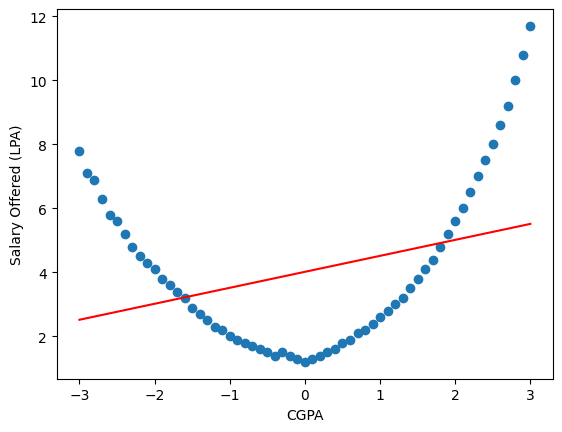

In [96]:
# drawing the scatter plot
plt.scatter(X, y)
# plot the prediction line 
plt.plot(X, lr.predict(X), color='red')
plt.xlabel("CGPA")
plt.ylabel("Salary Offered (LPA)")
plt.show()

In [97]:
rr = Ridge(alpha=10)
rr.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [98]:
y_pred = rr.predict(X_test)
print("R-squared:", (r2_score(y_test, y_pred)*100))
print("Intercept:", rr.intercept_)
print("Coefficients:", rr.coef_)

R-squared: 3.1052909148962637
Intercept: [4.01541756]
Coefficients: [0.46680956]


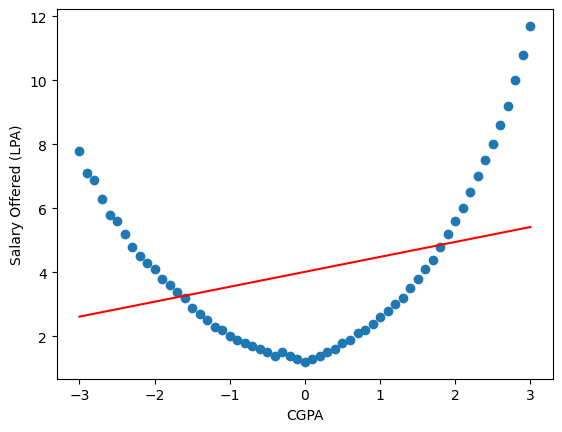

In [99]:
# drawing the scatter plot
plt.scatter(X, y)
# plot the prediction line 
plt.plot(X, rr.predict(X), color='red')
plt.xlabel("CGPA")
plt.ylabel("Salary Offered (LPA)")
plt.show()

In [108]:
# def trainModel(X_train, y_train, X_test, y_test, alpha, degree):

#     model = Pipeline([
#         ("polynomialPipeline", PolynomialFeatures(degree=degree, include_bias=False)),
#         # ("ridge", Ridge(alpha=alpha))
#         ("lsso", Lasso(alpha=alpha ))
#     ])

#     model.fit(X_train, y_train)

#     y_pred = model.predict(X_test)

#     print("R-squared:", r2_score(y_test, y_pred) * 100)
#     # print("Intercept:", model.named_steps["ridge"].intercept_)
#     # print("Coefficients:", model.named_steps["ridge"].coef_)
#     # polynomial feature get out
#     print(f"PolynomialFeatures {model.named_steps['polynomialPipeline'].get_feature_names_out()}")
#     print("Intercept:", model.named_steps["lsso"].intercept_)
#     print("Coefficients:", model.named_steps["lsso"].coef_)

#     X_sorted = X.sort_values(by="X")

#     plt.figure(figsize=(10,6))
#     plt.scatter(X, y)
#     plt.plot(X_sorted, model.predict(X_sorted), color="red", linewidth=2)
#     plt.xlabel("CGPA")
#     plt.ylabel("Salary Offered (LPA)")
#     plt.show()


#     return model

In [ ]:
def train_and_save(X_train, y_train, X_test, y_test, alpha, degree):
    
    # Create model
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lasso", Lasso(alpha=alpha))
    ])
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Print results
    print(f"\n--- Lasso (alpha={alpha}, degree={degree}) ---")
    print(f"R² Score: {r2_score(y_test, y_pred)*100:.2f}%")
    
    # Get features and coefficients
    features = model.named_steps['poly'].get_feature_names_out()
    coefs = model.named_steps['lasso'].coef_
    
    print("Features:", features)
    print("Coefficients:", coefs)
    
    # Show which features are kept/removed
    kept = features[coefs != 0]
    removed = features[coefs == 0]
    print(f"Kept: {kept}")
    print(f"Removed: {removed}")
    
    # Save new dataset with only important features
    if len(kept) > 0:
        # Create polynomial features
        X_poly = model.named_steps['poly'].transform(X)
        X_poly_df = pd.DataFrame(X_poly, columns=features)
        
        # Keep only important features + target
        new_df = X_poly_df[kept]
        new_df['Y'] = y.values
        
        # Save
        new_df.to_csv(f"new_data_alpha_{alpha}.csv", index=False)
        print(f"✅ Saved: new_data_alpha_{alpha}.csv")
        print(f"New shape: {new_df.shape}\n")
    
    # Plot
    X_sorted = X.sort_values(by="X")
    plt.figure(figsize=(8,5))
    plt.scatter(X, y, alpha=0.5)
    plt.plot(X_sorted, model.predict(X_sorted), 'r-', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Lasso Regression (alpha={alpha})")
    plt.show()
    
    return model

TESTING LASSO WITH DIFFERENT ALPHA VALUES

--- Lasso (alpha=0.01, degree=3) ---
R² Score: 99.67%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0.1646239  0.88013263 0.05533783]
Kept: ['X' 'X^2' 'X^3']
Removed: []
✅ Saved: new_data_alpha_0.01.csv
New shape: (61, 4)



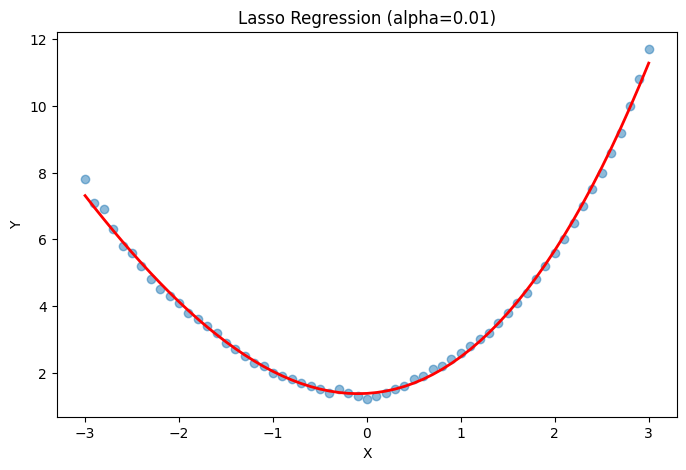


--- Lasso (alpha=0.1, degree=3) ---
R² Score: 99.27%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0.0053913  0.86819401 0.07915322]
Kept: ['X' 'X^2' 'X^3']
Removed: []
✅ Saved: new_data_alpha_0.1.csv
New shape: (61, 4)



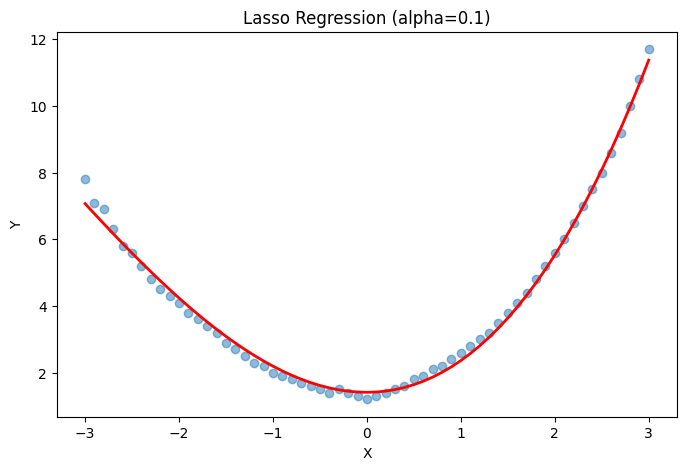


--- Lasso (alpha=1, degree=3) ---
R² Score: 96.51%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0.         0.74596603 0.07212264]
Kept: ['X^2' 'X^3']
Removed: ['X']
✅ Saved: new_data_alpha_1.csv
New shape: (61, 3)



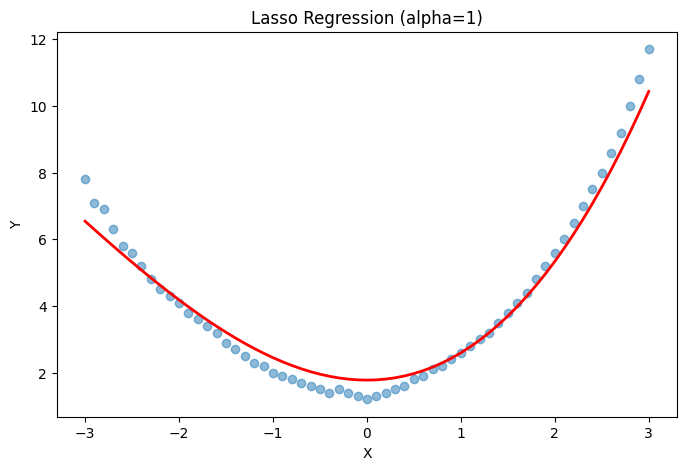


--- Lasso (alpha=10, degree=3) ---
R² Score: -2.77%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0. 0. 0.]
Kept: []
Removed: ['X' 'X^2' 'X^3']


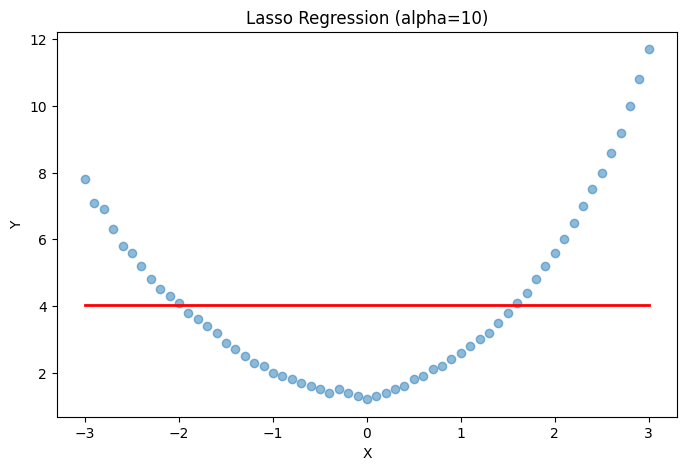


--- Lasso (alpha=50, degree=3) ---
R² Score: -2.77%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0. 0. 0.]
Kept: []
Removed: ['X' 'X^2' 'X^3']


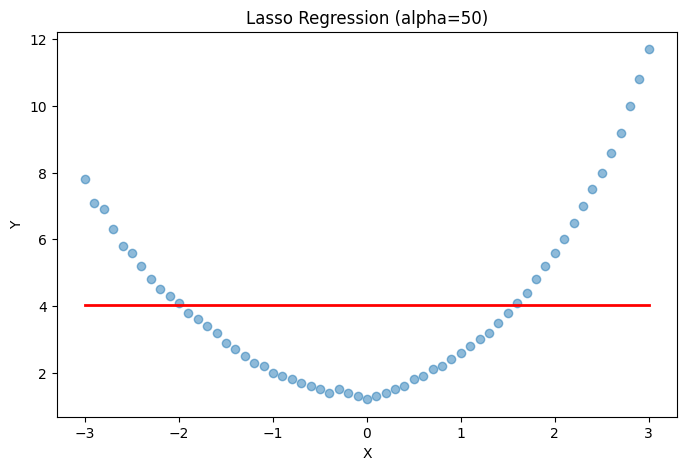


--- Lasso (alpha=100, degree=3) ---
R² Score: -2.77%
Features: ['X' 'X^2' 'X^3']
Coefficients: [0. 0. 0.]
Kept: []
Removed: ['X' 'X^2' 'X^3']


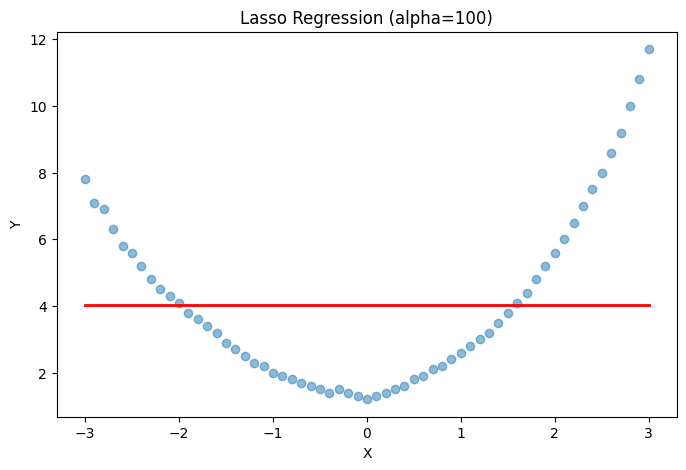

In [113]:
# 4. TRY DIFFERENT ALPHA VALUES
print("="*50)
print("TESTING LASSO WITH DIFFERENT ALPHA VALUES")
print("="*50)

# Try different alphas to see feature selection
for alpha in [0.01, 0.1, 1, 10, 50, 100]:
    train_and_save(X_train, y_train, X_test, y_test, alpha, degree=3)

In [102]:
lsso = Lasso(alpha=10)
lsso.fit(X_train, y_train)

y_pred_lsso = lsso.predict(X_test)
print("R-squared:", (r2_score(y_test, y_pred_lsso)*100))
print("Intercept:", lsso.intercept_)
print("Coefficients:", lsso.coef_)

R-squared: -2.770621617615765
Intercept: [4.0125]
Coefficients: [0.]


In [103]:
newdf = pd.read_csv("/Users/mohddanish/Desktop/Machine_Learning/MachineLearning/new_data_alpha_1.csv")

In [ ]:
newdf

,X^2,X^3,Y
0,9.00,-27.000,7.8
1,8.41,-24.389,7.1
2,7.84,-21.952,6.9
3,7.29,-19.683,6.3
4,6.76,-17.576,5.8
...,...,...,...
56,6.76,17.576,8.6
57,7.29,19.683,9.2
58,7.84,21.952,10.0
59,8.41,24.389,10.8


: 

In [104]:
X_new = newdf[["X^2", "X^3"]]
y_new = newdf[["Y"]]

In [105]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [106]:
newlr = LinearRegression()
newlr.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [107]:
y_pred_newlr = newlr.predict(X_test2)
print("R-squared:", (r2_score(y_test2, y_pred_newlr)*100))
print("Intercept:", newlr.intercept_)
print("Coefficients:", newlr.coef_)

R-squared: 99.33602462073507
Intercept: [1.36638126]
Coefficients: [[0.88178447 0.08085992]]
